## Prediccion — Regresion lineal de precios

Estima `precio_log` a partir de variables climaticas. Reporta tabla OLS con coeficientes, p-valores y significancia.

---

### Descripcion del Modelo

El modelo implementado corresponde a una **regresion lineal ordinaria (OLS)** que estima el logaritmo del precio (`precio_log`) a partir de cuatro variables climaticas:

- **Temperatura** (°C)
- **Humedad** (%)
- **Precipitaciones** (mm)
- **Radiacion UV** (indice)

Se construye un modelo independiente para cada uno de los seis productos analizados: Limon, Naranja, Palta, Papa, Tomate y Uva. El objetivo es aislar la fuerza predictiva de cada variable climatica sobre el precio logaritmico, cuantificando tanto la direccion como la magnitud del efecto.

> **Nota:** Los coeficientes corresponden a efectos sobre el precio en escala logaritmica. Para interpretarlos en terminos porcentuales, se aplica la transformacion: `% cambio ≈ (e^{coef} − 1) × 100`.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from pymongo import MongoClient
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("=" * 80)
print("CARGA DE DATOS DESDE MONGODB")
print("=" * 80)

load_dotenv("/home/jovyan/work/.env")
load_dotenv("../.env")
load_dotenv()

try:
    client = MongoClient(os.getenv("MONGO_URI"), serverSelectionTimeoutMS=15000)
    client.admin.command("ping")
    db = client[os.getenv("DB_NAME", "db_g9agrotech")]
    processed = db[os.getenv("PROCESSED_COLLECTION", "processed_data")]
    df = pd.DataFrame(list(processed.find({})))
    if df.empty:
        raise ValueError("La coleccion procesada esta vacia.")
    print(f"Registros cargados: {len(df):,}")
except Exception as exc:
    raise RuntimeError(f"No se pudo cargar MongoDB: {exc}")

CARGA DE DATOS DESDE MONGODB
Registros cargados: 7,021


In [2]:
print("\n" + "=" * 80)
print("LIMPIEZA Y PREPARACION")
print("=" * 80)

PRODUCTOS = ["Limón", "Naranja", "Palta", "Papa", "Tomate", "Uva"]
FEATURES = ["temperatura", "humedad", "precipitaciones", "radiacion_uv"]
TARGET = "precio_log"

df = df[df["producto"].notna()].drop_duplicates()
df = df[df["producto"].str.lower() != "petroleo"]
df = df[df["producto"].isin(PRODUCTOS)]

for col in [
    "precio_petroleo", "precio_petroleo_contexto", "tasa_cambio",
    "lugar_monitoreo", "mes_num", "comuna",
]:
    if col in df.columns:
        df = df.drop(columns=[col])

for col in ["precio"] + FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if "fecha" in df.columns:
    df["fecha_dt"] = pd.to_datetime(df["fecha"], errors="coerce", dayfirst=True)
else:
    df["fecha_dt"] = pd.NaT

df = df.dropna(subset=["precio", "producto"] + FEATURES)
df[TARGET] = np.log1p(df["precio"])

print(f"Registros listos: {len(df):,}")
print(f"Productos: {sorted(df['producto'].unique())}")


LIMPIEZA Y PREPARACION
Registros listos: 6,655
Productos: ['Limón', 'Naranja', 'Palta', 'Papa', 'Tomate', 'Uva']


### Modelos OLS por producto

Tabla tipica: coeficiente, error estandar, t, p-valor, IC 95% y significancia (p < 0.05).

In [3]:
import statsmodels.api as sm

NIVEL_SIGNIFICANCIA = 0.05


def split_temporal(dataframe, test_ratio=0.2):
    df_split = dataframe.copy()
    if "fecha_dt" not in df_split.columns and "fecha" in df_split.columns:
        df_split["fecha_dt"] = pd.to_datetime(df_split["fecha"], errors="coerce", dayfirst=True)
    if "fecha_dt" in df_split.columns and df_split["fecha_dt"].notna().any():
        ordered = df_split.sort_values("fecha_dt")
    else:
        ordered = df_split.sample(frac=1, random_state=42)
    split_idx = max(1, int(len(ordered) * (1 - test_ratio)))
    train = ordered.iloc[:split_idx]
    test = ordered.iloc[split_idx:]
    if len(test) == 0:
        test = train.sample(frac=test_ratio, random_state=42)
        train = train.drop(test.index)
    return train, test


def tabla_regresion(ols, producto):
    ic = ols.conf_int(alpha=NIVEL_SIGNIFICANCIA)
    return pd.DataFrame({
        "producto": producto,
        "variable": ols.params.index,
        "coeficiente": ols.params.values,
        "error_std": ols.bse.values,
        "estadistico_t": ols.tvalues.values,
        "p_valor": ols.pvalues.values,
        "ic_95_inf": ic[0].values,
        "ic_95_sup": ic[1].values,
        "sig": np.where(ols.pvalues.values < NIVEL_SIGNIFICANCIA, "Si", "No"),
    })


tablas = []
resumenes = []
graficos = {}

print("\n" + "=" * 80)
print("MODELOS OLS POR PRODUCTO")
print("=" * 80)

for producto in PRODUCTOS:
    df_p = df[df["producto"] == producto].copy()
    if len(df_p) < 30:
        print(f"\n{producto}: datos insuficientes")
        continue

    train, test = split_temporal(df_p)
    x_train = sm.add_constant(train[FEATURES].astype(float), has_constant="add")
    x_test = sm.add_constant(test[FEATURES].astype(float), has_constant="add")
    x_test = x_test[x_train.columns]
    y_train, y_test = train[TARGET], test[TARGET]

    ols = sm.OLS(y_train, x_train).fit()
    pred_log = ols.predict(x_test)
    pred_clp = np.expm1(pred_log)
    real_clp = np.expm1(y_test)

    tablas.append(tabla_regresion(ols, producto))
    resumenes.append({
        "producto": producto,
        "n_train": len(train),
        "n_test": len(test),
        "r2_ajustado": ols.rsquared_adj,
        "f_p_valor": ols.f_pvalue,
        "r2_test_log": r2_score(y_test, pred_log),
        "mae_clp": mean_absolute_error(real_clp, pred_clp),
        "rmse_clp": np.sqrt(mean_squared_error(real_clp, pred_clp)),
    })
    graficos[producto] = {"real_clp": real_clp, "pred_clp": pred_clp}

    print(f"\n{'─'*80}")
    print(f"PRODUCTO: {producto}")
    print(ols.summary())

tabla_coeficientes = pd.concat(tablas, ignore_index=True)
tabla_modelos = pd.DataFrame(resumenes)

print("\n" + "=" * 80)
print("TABLA CONSOLIDADA DE COEFICIENTES")
print("=" * 80)
print(
    tabla_coeficientes.round({
        "coeficiente": 4, "error_std": 4, "estadistico_t": 3,
        "p_valor": 4, "ic_95_inf": 4, "ic_95_sup": 4,
    }).to_string(index=False)
)

print("\n" + "=" * 80)
print("RESUMEN DE AJUSTE POR PRODUCTO")
print("=" * 80)
print(tabla_modelos.round(4).to_string(index=False))


MODELOS OLS POR PRODUCTO

────────────────────────────────────────────────────────────────────────────────
PRODUCTO: Limón
                            OLS Regression Results                            
Dep. Variable:             precio_log   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     10.08
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           5.09e-08
Time:                        22:36:51   Log-Likelihood:                -876.97
No. Observations:                1122   AIC:                             1764.
Df Residuals:                    1117   BIC:                             1789.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--

### Ecuaciones Lineales por Producto

A partir de los coeficientes estimados, las ecuaciones de regresion para cada producto son:

| Producto | Ecuacion |
|----------|----------|
| **Limon** | `precio_log = 6.5052 + 0.0267·temperatura + 0.00002·humedad − 0.0108·precipitaciones + 0.0122·radiacion_uv` |
| **Naranja** | `precio_log = 7.0539 + 0.0059·temperatura − 0.0001·humedad − 0.0164·precipitaciones + 0.0104·radiacion_uv` |
| **Palta** | `precio_log = 8.1803 + 0.0115·temperatura − 0.0003·humedad − 0.0007·precipitaciones + 0.0065·radiacion_uv` |
| **Papa** | `precio_log = 6.7158 + 0.0035·temperatura − 0.0010·humedad − 0.0120·precipitaciones + 0.0035·radiacion_uv` |
| **Tomate** | `precio_log = 7.0059 − 0.0147·temperatura + 0.0024·humedad − 0.0137·precipitaciones − 0.0011·radiacion_uv` |
| **Uva** | `precio_log = 8.0565 − 0.0101·temperatura − 0.0020·humedad − 0.0296·precipitaciones − 0.0135·radiacion_uv` |

---

### Resultados Estadisticamente Significativos

| Producto | Variable | Coeficiente | p-valor | Interpretacion |
|----------|----------|-------------|---------|----------------|
| **Limon** | Temperatura | +0.0267 | 0.0000 | Por cada °C de aumento, el precio aumenta ~2.7% |
| **Limon** | Radiacion UV | +0.0122 | 0.0435 | Por cada unidad UV, el precio aumenta ~1.2% |
| **Naranja** | Precipitaciones | -0.0164 | 0.0032 | Por cada mm de lluvia, el precio baja ~1.6% |
| **Palta** | Temperatura | +0.0115 | 0.0015 | Por cada °C de aumento, el precio aumenta ~1.2% |
| **Tomate** | Temperatura | -0.0147 | 0.0418 | Por cada °C de aumento, el precio baja ~1.5% |

**Resumen ejecutivo:**
- **Limon** es el producto con mayor poder explicativo (R² = 0.035) y el unico con dos variables climaticas significativas.
- **Palta** y **Naranja** tienen una variable significativa cada uno.
- **Tomate** muestra una relacion negativa con la temperatura.
- **Papa** y **Uva** no presentan variables climaticas significativas (p > 0.05).

### Interpretaciones de Negocio

Las siguientes interpretaciones se derivan de los resultados del modelo y se vinculan con las problematicas descritas en la propuesta de negocio.

#### 4.1. Mitigacion de Riesgos por Factores Climaticos

**Palta — Sensibilidad positiva a la temperatura**
Los resultados indican que cuando la temperatura aumenta, el precio de la palta tiende a subir. Esto puede interpretarse como un indicador de **escasez relativa**: en periodos de altas temperaturas, los arboles de palto pueden verse estresados o la maduracion se acelera, reduciendo la oferta disponible en el mercado. Los agricultores que monitoreen las proyecciones de temperatura podran anticipar ventanas de menor oferta y ajustar su estrategia de venta para capturar precios mas altos.

> **Accion recomendada:** En anos o temporadas con pronostico de temperaturas mas altas de lo normal, los productores de palta deberian considerar almacenar produccion para vender en momentos de escasez.

**Limon — Sensibilidad positiva a temperatura y radiacion UV**
El limon muestra la mayor sensibilidad climatica. Ambos factores (temperatura y radiacion UV) tienen efectos positivos sobre el precio. Esto sugiere que condiciones de mayor estres termico (propias del verano en la Region de Coquimbo) reducen la oferta disponible, elevando los precios. Este insight permite a los productores planificar cosechas anticipadas o tardias segun las proyecciones climaticas estacionales.

> **Accion recomendada:** Integrar datos de pronostico de temperatura y radiacion UV en el calendario de decisiones de cosecha y venta para el limon.

**Naranja — Sensibilidad negativa a las precipitaciones**
A diferencia de otros productos, las lluvias tienen un efecto negativo sobre el precio de la naranja. Esto podria deberse a que las precipitaciones favorecen una mayor produccion o aceleracion de la maduracion, generando mayor oferta en el mercado. En temporadas lluviosas, los precios tienden a disminuir.

> **Accion recomendada:** En temporadas con mayores precipitaciones, los productores de naranja deberian considerar vender antes para evitar la caida de precios por sobreoferta.

**Tomate — Relacion inversa con la temperatura**
El modelo revela que cuando la temperatura sube, el precio del tomate baja. Esto puede explicarse porque el calor acelera la maduracion masiva del tomate, generando picos de oferta que saturan el mercado. Es el unico producto con esta relacion negativa significativa.

> **Accion recomendada:** En periodos de temperaturas elevadas, los productores de tomate deben gestionar la venta de manera mas agil para evitar perdidas por sobremaduracion o saturacion del mercado.

---

#### 4.2. Planificacion Estrategica y Perfilamiento Estadistico

Los R² ajustados bajos (entre 0.002 y 0.035) confirman lo que la propuesta de negocio anticipaba: **la experiencia historica no basta para explicar la variabilidad de precios**. Los factores climaticos alone explican solo una fraccion minima de las fluctuaciones. Esto valida la necesidad de un enfoque multidimensional que considere:

- Indices de precio internacionales (diesiel, tasa de cambio)
- Canales de venta y su estabilidad temporal
- Ciclos estacionales de oferta y demanda

Sin embargo, los resultados significativos demuestran que **si existe señal climatica exploitable**, especialmente para productos como el limon y la palta.

---

#### 4.3. Inteligencia de Distribucion Logistica y Comercial

Aunque el modelo actual no incluye variables de canal de venta (feria libre vs. supermercado), los resultados diferenciados por producto sugieren que cada cultivo tiene su propio perfil de sensibilidad climatica:

- **Productos con alta sensibilidad climatica** (Limon, Palta) pueden beneficiarse de la segmentacion de mercados: vender en supermercados donde los precios son mas estables, o timing de venta mas controlado.
- **Productos con baja sensibilidad climatica** (Papa, Uva) pueden destinarse a canales donde el precio es menos relevante que el volumen (ferias libres, venta directa).

---

#### 4.4. Limitaciones del Modelo y Proximos Pasos

Los resultados deben interpretarse con cautela:

1. **Bajo poder explicativo:** Los R² son bajos porque los precios agricolas dependen de multiples factores no incluidos en el modelo (oferta agregada, demanda externa, costos de transporte, estacionalidad de cosechas).
2. **Multicolinealidad potencial:** Las variables climaticas pueden estar correlacionadas entre si, lo que podria inflar o reducir los coeficientes individuales.
3. **Datos temporales:** El modelo usa un split temporal simple; series de tiempo mas sofisticadas (ARIMA, Prophet) podrian capturar patrones ciclicos no lineales.

---

### Conclusion

El analisis de regresion lineal confirma parcialmente las hipotesis de la propuesta de negocio:

1. **Si existe influencia climatica cuantificable** sobre los precios de ciertos productos (Limon, Palta, Naranja, Tomate).
2. **La informacion climatica permite anticipar tendencias**, pero no explica la totalidad de la variabilidad de precios.
3. **Los productores pueden usar estos insights para planificar estrategicamente** sus decisiones de cosecha y venta, especialmente para productos con alta sensibilidad climatica.

La propuesta de valor del scraping —convertir datos dispersos en informacion accionable— se materializa en estas interpretaciones que permiten pasar de decisiones "a ciegas" a decisiones basadas en evidencia.

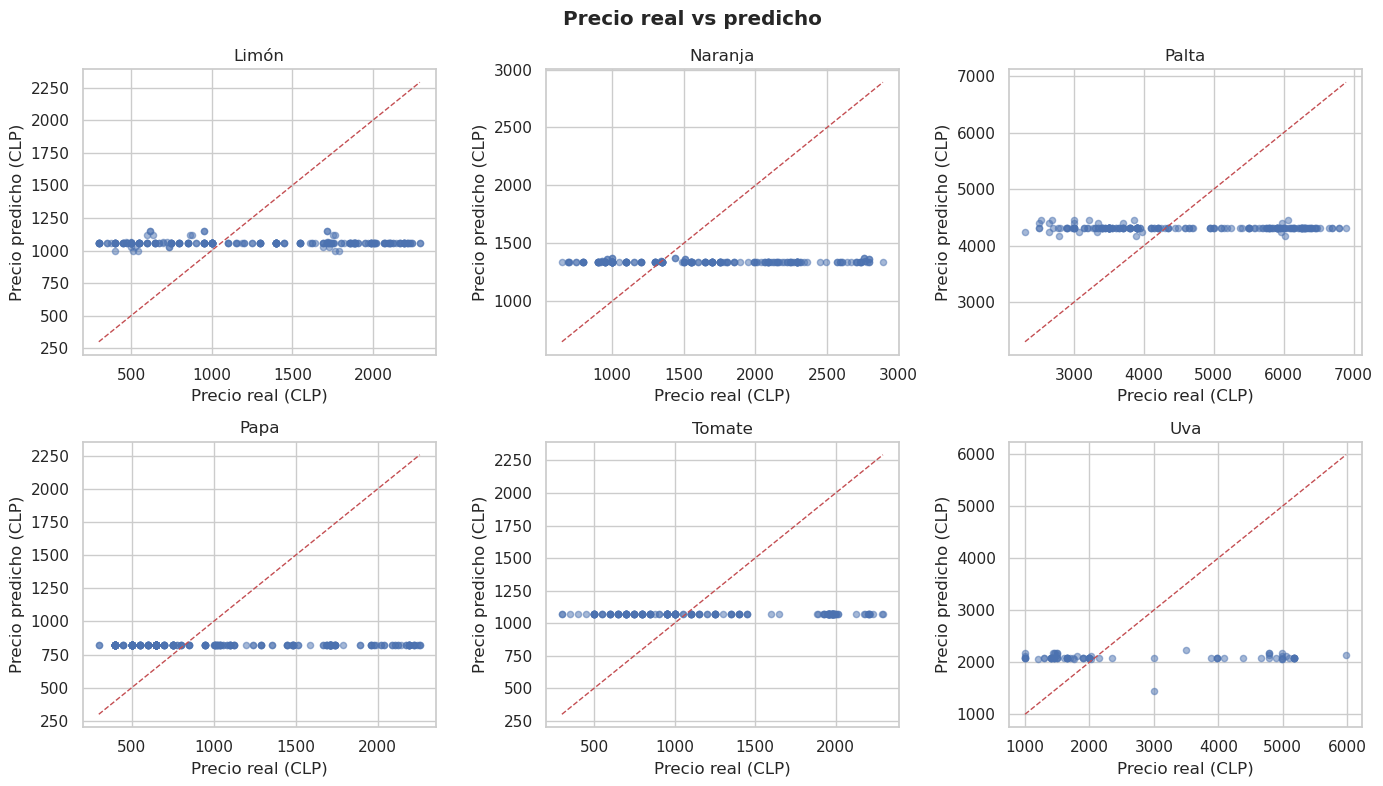

In [4]:
if graficos:
    n_cols = 3
    n_rows = int(np.ceil(len(graficos) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (producto, datos) in zip(axes, graficos.items()):
        real_clp = datos["real_clp"]
        pred_clp = datos["pred_clp"]
        ax.scatter(real_clp, pred_clp, alpha=0.5, s=20)
        lim_min = min(real_clp.min(), pred_clp.min())
        lim_max = max(real_clp.max(), pred_clp.max())
        ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=1)
        ax.set_title(producto)
        ax.set_xlabel("Precio real (CLP)")
        ax.set_ylabel("Precio predicho (CLP)")

    for ax in axes[len(graficos):]:
        ax.axis("off")

    fig.suptitle("Precio real vs predicho", fontweight="bold")
    plt.tight_layout()
    plt.show()